In [114]:
# 1. SETUP & IMPORTS


!pip install -q pandas numpy scikit-learn tensorflow matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score

from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Conv1D, MaxPooling1D, Dropout,
    BatchNormalization, Bidirectional, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam


In [115]:
# 2. GOOGLE DRIVE + GPU CHECK

from google.colab import drive
drive.mount('/content/drive')

def system_check():
    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU detected:", gpus[0].name)
    else:
        print("NO GPU FOUND")

system_check()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NO GPU FOUND


In [116]:
# 3. CONFIGURATION

CONFIG = {
    "SEED": 42,
    "SEQ_LEN": 180,
    "BATCH_SIZE": 64,
    "EPOCHS": 2000,
    "TEST_SIZE": 0.2,
    "LEARNING_RATE": 1e-3,
    "CNN_FILTERS": 128,
    "LSTM_UNITS": 128,
    "DROPOUT": 0.5,
    "DENSE_UNITS": 128
}

os.environ['PYTHONHASHSEED'] = str(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])
random.seed(CONFIG["SEED"])
tf.random.set_seed(CONFIG["SEED"])


In [117]:
# 4. LOAD + CLEAN + BUILD TENSORS

def load_and_process_data():

    BASE = "/content/drive/MyDrive/nn/proje/"

    train_df = pd.read_csv(BASE + "pirate_pain_train.csv")
    test_df  = pd.read_csv(BASE + "pirate_pain_test.csv")
    train_labels = pd.read_csv(BASE + "pirate_pain_train_labels.csv")

    # Remove broken col if included
    for df in [train_df, test_df]:
        if "joint_30" in df.columns:
            df.drop(columns=["joint_30"], inplace=True)

    CAT_COLS = ["n_legs", "n_hands", "n_eyes"]

    # Static features per sample_index
    train_static = train_df.groupby("sample_index")[CAT_COLS].first().reset_index()
    test_static  = test_df.groupby("sample_index")[CAT_COLS].first().reset_index()

    train_static_oh = pd.get_dummies(train_static, columns=CAT_COLS)
    test_static_oh  = pd.get_dummies(test_static, columns=CAT_COLS)

    # Align one-hot columns
    train_static_oh, test_static_oh = train_static_oh.align(test_static_oh, axis=1, fill_value=0)

    # Convert  numbers
    text_map = {'one':1,'two':2,'three':3,'four':4,'five':5}

    def clean(df):
        df = df.copy()
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].replace(text_map)
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        return df

    train_df = clean(train_df)
    test_df = clean(test_df)

    TS_FEATURES = [
        c for c in train_df.columns
        if c not in ["sample_index", "time", "n_legs", "n_hands", "n_eyes"]
    ]
    n_ts = len(TS_FEATURES)

    def build_tensor(df, static_df):
        ids = df.sample_index.unique()
        ids.sort()

        N = len(ids)
        X_ts = np.zeros((N, CONFIG["SEQ_LEN"], n_ts))

        static = static_df.sort_values("sample_index").drop(columns=["sample_index"]).values
        static_rep = np.repeat(static[:, None, :], CONFIG["SEQ_LEN"], axis=1)

        for i, sid in enumerate(ids):
            sub = df[df.sample_index == sid].sort_values("time")
            arr = sub[TS_FEATURES].values
            L = len(arr)

            if L >= CONFIG["SEQ_LEN"]:
                X_ts[i] = arr[:CONFIG["SEQ_LEN"]]
            else:
                X_ts[i, :L] = arr

        return np.concatenate([X_ts, static_rep], axis=-1), ids

    X_train_raw, train_ids = build_tensor(train_df, train_static_oh)
    X_test_raw,  test_ids  = build_tensor(test_df,  test_static_oh)

    # Labels
    label_map = train_labels.set_index("sample_index")["label"]
    y_list = [label_map[s] for s in train_ids]

    le = LabelEncoder()
    y_int = le.fit_transform(y_list)
    y_cat = to_categorical(y_int)

    return X_train_raw, y_cat, X_test_raw, le

X_all, y_all, X_submission, label_encoder = load_and_process_data()


In [118]:

# 5. SPLIT + SCALE


X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["SEED"],
    stratify=y_all
)

y_train_int = np.argmax(y_train, axis=1)
num_classes = y_train.shape[1]

scaler = StandardScaler()

def scale_tensor(X):
    N, T, F = X.shape
    return scaler.fit_transform(X.reshape(N*T, F)).reshape(N, T, F)

X_train_scaled = scale_tensor(X_train)
X_val_scaled   = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_sub_scaled   = scaler.transform(X_submission.reshape(-1, X_submission.shape[-1])).reshape(X_submission.shape)


In [119]:
# 6. BALANCED BATCH GENERATOR


class BalancedBatchGenerator(Sequence):
    def __init__(self, X, y_hot, y_int, batch_size, num_classes):
        self.X = X
        self.y_hot = y_hot
        self.y_int = y_int
        self.batch_size = batch_size
        self.num_classes = num_classes

        # Indices per class
        self.class_idx = {c: np.where(y_int == c)[0] for c in range(num_classes)}
        self.per_class = batch_size // num_classes

        self.steps = min(len(v) for v in self.class_idx.values()) // self.per_class
        self.on_epoch_end()

    def __len__(self):
        return self.steps

    def on_epoch_end(self):
        self.epoch_idx = []
        for c in range(self.num_classes):
            idx = np.copy(self.class_idx[c])
            np.random.shuffle(idx)
            needed = self.steps * self.per_class
            self.epoch_idx.append(np.tile(idx, needed // len(idx) + 1)[:needed])

    def __getitem__(self, i):
        idx = []
        start = i * self.per_class
        for c in range(self.num_classes):
            idx.extend(self.epoch_idx[c][start:start+self.per_class])

        idx = np.array(idx)
        np.random.shuffle(idx)

        return self.X[idx], self.y_hot[idx]


In [120]:
# 7. F1 CALLBACK

class F1Callback(Callback):
    def __init__(self, X_val, y_val, patience=15):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience
        self.best_f1 = -1
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        y_true = np.argmax(self.y_val, axis=1)
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)

        f1 = f1_score(y_true, y_pred, average="macro")

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.wait = 0
            self.model.save_weights("best_f1.weights.h5")
        else:
            self.wait += 1

        if self.wait >= self.patience:
            print("⚠ Early stopping triggered (F1 did not improve).")
            self.model.stop_training = True


In [121]:

# 8. MODEL

def build_model(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = Conv1D(CONFIG["CNN_FILTERS"], 3, padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(CONFIG["LSTM_UNITS"], return_sequences=True))(x)
    x = Dropout(CONFIG["DROPOUT"])(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(CONFIG["DENSE_UNITS"], activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(CONFIG["DROPOUT"])(x)

    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(CONFIG["LEARNING_RATE"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model(X_train_scaled.shape[1:], num_classes)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 180, 128)       │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 180, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 90, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 90, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,963 (1.19 MB)

 Trainable params: 312,451 (1.19 MB)

 Non-trainable params: 512 (2.00 KB)

In [122]:
# 9. TRAIN


train_gen = BalancedBatchGenerator(
    X_train_scaled, y_train, y_train_int,
    CONFIG["BATCH_SIZE"], num_classes
)

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    F1Callback(X_val_scaled, y_val, patience=25)
]

history = model.fit(
    train_gen,
    validation_data=(X_val_scaled, y_val),
    epochs=CONFIG["EPOCHS"],
    verbose=1,
    callbacks=callbacks
)


Epoch 1/2000


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.4127 - loss: 1.6954 - val_accuracy: 0.2331 - val_loss: 1.0850 - learning_rate: 0.0010
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6032 - loss: 1.0804 - val_accuracy: 0.3083 - val_loss: 1.0684 - learning_rate: 0.0010
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7143 - loss: 0.7229 - val_accuracy: 0.3083 - val_loss: 1.0637 - learning_rate: 0.0010
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6720 - loss: 0.7045 - val_accuracy: 0.3383 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7566 - loss: 0.6770 - val_accuracy: 0.3609 - val_loss: 1.0694 - learning_rate: 0.0010
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7725 - loss: 0.5556 - val_accuracy: 0.3910 - val_loss: 1.0623 - learning_rate: 0.0010
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7989 - loss: 0.5653 - val_accuracy: 0.4436 - val_loss: 

In [123]:
# 10. FINAL VALIDATION F1

model.load_weights("best_f1.weights.h5")

y_pred = np.argmax(model.predict(X_val_scaled), axis=1)
y_true = np.argmax(y_val, axis=1)

print("FINAL VAL F1:", f1_score(y_true, y_pred, average='macro'))


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
FINAL VAL F1: 0.8618149597465764


In [124]:
# 11. SUBMISSION

sub_probs = model.predict(X_sub_scaled)
sub_preds = np.argmax(sub_probs, axis=1)
sub_labels = label_encoder.inverse_transform(sub_preds)

df_sub = pd.DataFrame({
    "sample_index": [f"{i:03d}" for i in range(len(sub_labels))],
    "label": sub_labels
})

df_sub.to_csv("/content/drive/MyDrive/nn/proje/submission2.csv", index=False)

print("Saved:", "/content/drive/MyDrive/nn/proje/submission2.csv")


42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step
Saved: /content/drive/MyDrive/nn/proje/submission2.csv


In [125]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  8   0   3]
 [  2  17   0]
 [  2   1 100]]


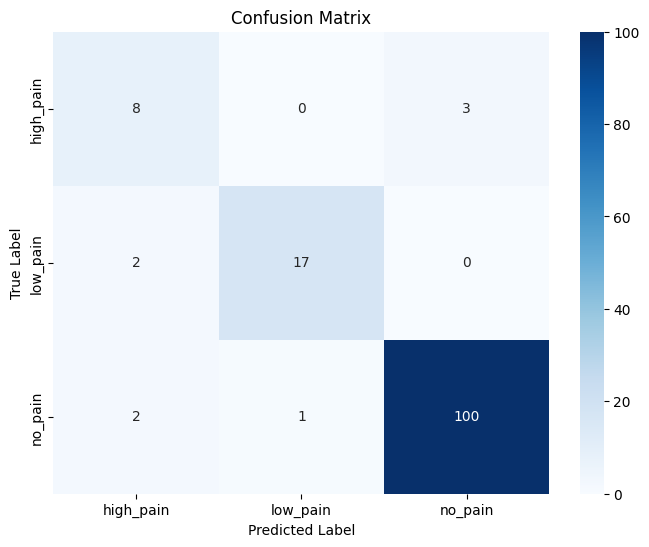

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class labels from label_encoder
class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [127]:
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
y_train_smote = y_train_int

print(f"Original X_train_scaled shape: {X_train_scaled.shape}")
print(f"Reshaped X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print(f"y_train_smote is 1D: {y_train_smote.ndim == 1}")

Original X_train_scaled shape: (528, 180, 40)
Reshaped X_train_reshaped shape: (528, 7200)
y_train_smote shape: (528,)
y_train_smote is 1D: True


In [128]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=CONFIG["SEED"])
X_train_smote_2d, y_train_smote_int = smote.fit_resample(X_train_reshaped, y_train_smote)

# Reshape X_train_smote_2d back to 3D for the CNN-LSTM model
X_train_smote = X_train_smote_2d.reshape(
    X_train_smote_2d.shape[0],
    CONFIG["SEQ_LEN"],
    X_train_scaled.shape[-1]
)

# Convert y_train_smote_int back to one-hot encoding
y_train_smote_hot = to_categorical(y_train_smote_int, num_classes=num_classes)

print(f"Original X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_smote shape after SMOTE and reshape: {X_train_smote.shape}")
print(f"y_train_smote_int shape after SMOTE: {y_train_smote_int.shape}")
print(f"y_train_smote_hot shape after one-hot encoding: {y_train_smote_hot.shape}")

Original X_train_scaled shape: (528, 180, 40)
X_train_smote shape after SMOTE and reshape: (1224, 180, 40)
y_train_smote_int shape after SMOTE: (1224,)
y_train_smote_hot shape after one-hot encoding: (1224, 3)


In [129]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_smote, y_train_smote_hot))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train_smote)).batch(CONFIG["BATCH_SIZE"])

# Validation data also as tf.data.Dataset for consistency, if desired, or keep as numpy array
# For now, keep validation data as is since it's already in the format expected by model.fit for validation_data

print(f"SMOTE-augmented training dataset created with batch size: {CONFIG['BATCH_SIZE']}")

SMOTE-augmented training dataset created with batch size: 64


In [130]:
del model
tf.keras.backend.clear_session()

model = build_model(X_train_smote.shape[1:], num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 180, 128)       │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 90, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,963 (1.19 MB)

 Trainable params: 312,451 (1.19 MB)

 Non-trainable params: 512 (2.00 KB)

In [131]:
callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    F1Callback(X_val_scaled, y_val, patience=25)
]

history = model.fit(
    train_dataset, # Use the new tf.data.Dataset for training
    validation_data=(X_val_scaled, y_val),
    epochs=CONFIG["EPOCHS"],
    verbose=1,
    callbacks=callbacks
)

Epoch 1/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 755ms/step - accuracy: 0.6489 - loss: 0.9110 - val_accuracy: 0.7594 - val_loss: 0.6680 - learning_rate: 0.0010
Epoch 2/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 600ms/step - accuracy: 0.8976 - loss: 0.2945 - val_accuracy: 0.7970 - val_loss: 0.5541 - learning_rate: 0.0010
Epoch 3/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 566ms/step - accuracy: 0.9446 - loss: 0.1711 - val_accuracy: 0.8195 - val_loss: 0.4599 - learning_rate: 0.0010
Epoch 4/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 647ms/step - accuracy: 0.9526 - loss: 0.1382 - val_accuracy: 0.8421 - val_loss: 0.3935 - learning_rate: 0.0010
Epoch 5/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 622ms/step - accuracy: 0.9715 - loss: 0.0996 - val_accuracy: 0.8571 - val_loss: 0.3350 - learning_rate: 0.0010
Epoch 6/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 624ms/step - accuracy: 0.9738 - loss: 0.0814 - val_accuracy: 0.8947 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 7/2000
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 512ms/step - accuracy: 0.9

In [132]:
model.load_weights("best_f1.weights.h5")

y_pred_retrained = np.argmax(model.predict(X_val_scaled, verbose=0), axis=1)
y_true_retrained = np.argmax(y_val, axis=1)

final_val_f1_retrained = f1_score(y_true_retrained, y_pred_retrained, average="macro")
print("FINAL VAL F1 (after SMOTE):", final_val_f1_retrained)

FINAL VAL F1 (after SMOTE): 0.849041349041349


In [133]:
cm_retrained = confusion_matrix(y_true_retrained, y_pred_retrained)
print("Confusion Matrix (after SMOTE):")
print(cm_retrained)

Confusion Matrix (after SMOTE):
[[  7   0   4]
 [  1  17   1]
 [  2   1 100]]


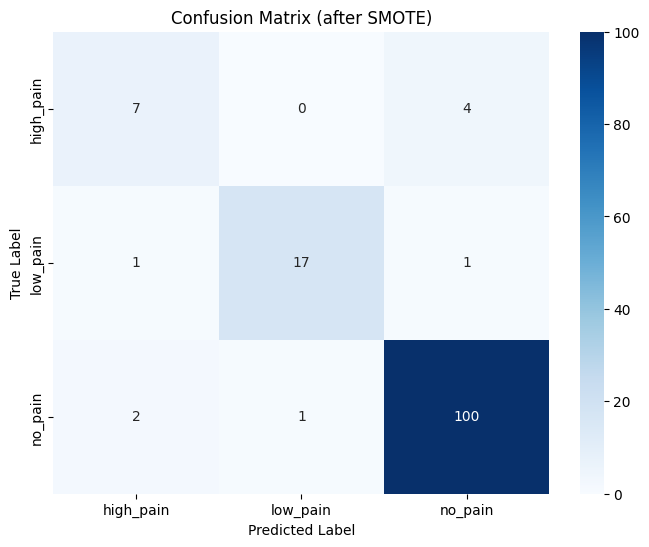

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class labels from label_encoder
class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm_retrained, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (after SMOTE)')
plt.show()

In [135]:
sub_probs_retrained = model.predict(X_sub_scaled, verbose=0)
sub_preds_retrained = np.argmax(sub_probs_retrained, axis=1)
sub_labels_retrained = label_encoder.inverse_transform(sub_preds_retrained)

print("Shape of sub_probs_retrained:", sub_probs_retrained.shape)
print("Shape of sub_preds_retrained:", sub_preds_retrained.shape)
print("First 5 sub_labels_retrained:", sub_labels_retrained[:5])

Shape of sub_probs_retrained: (1324, 3)
Shape of sub_preds_retrained: (1324,)
First 5 sub_labels_retrained: ['no_pain' 'no_pain' 'no_pain' 'no_pain' 'no_pain']


In [136]:
df_sub_retrained = pd.DataFrame({
    "sample_index": [f"{i:03d}" for i in range(len(sub_labels_retrained))],
    "label": sub_labels_retrained
})

output_path = "/content/drive/MyDrive/nn/proje/submission4.csv"
df_sub_retrained.to_csv(output_path, index=False)

print(f"Saved submission file to: {output_path}")

Saved submission file to: /content/drive/MyDrive/nn/proje/submission4.csv
